# Análisis y Predicción de Precios de Vehículos

Este notebook incluye:
1. Carga y preprocesamiento de datos
2. Análisis exploratorio (EDA)
3. Ingeniería de características
4. Entrenamiento del modelo
5. Evaluación y predicciones

In [11]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Configuración de visualización
%matplotlib inline
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## 1. Carga y Preprocesamiento de Datos

In [12]:
# Cargar dataset
df = pd.read_csv('../datasets/CAR DETAILS FROM CAR DEKHO.csv')

# Mostrar primeras filas y información básica
print("Primeras filas del dataset:")
display(df.head())

print("\nInformación del dataset:")
display(df.info())

Primeras filas del dataset:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


None

## 2. Análisis Exploratorio de Datos (EDA)

Estadísticas descriptivas:


,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


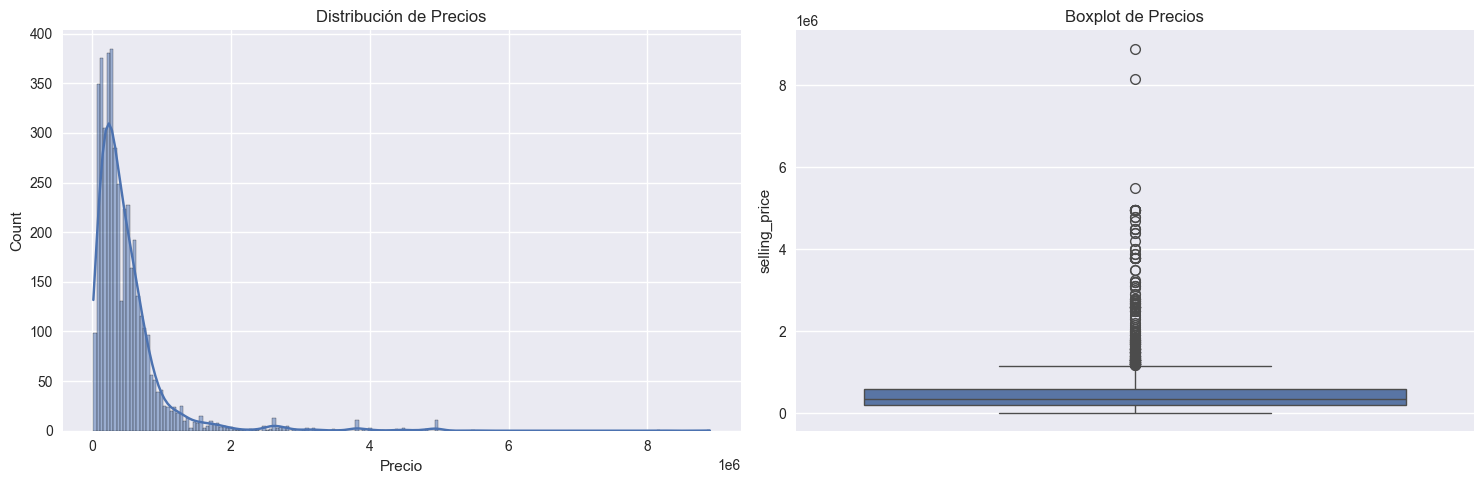

In [13]:
# Estadísticas descriptivas
print("Estadísticas descriptivas:")
display(df.describe())

# Distribución de precios
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['selling_price'], kde=True)
plt.title('Distribución de Precios')
plt.xlabel('Precio')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['selling_price'])
plt.title('Boxplot de Precios')
plt.tight_layout()
plt.show()

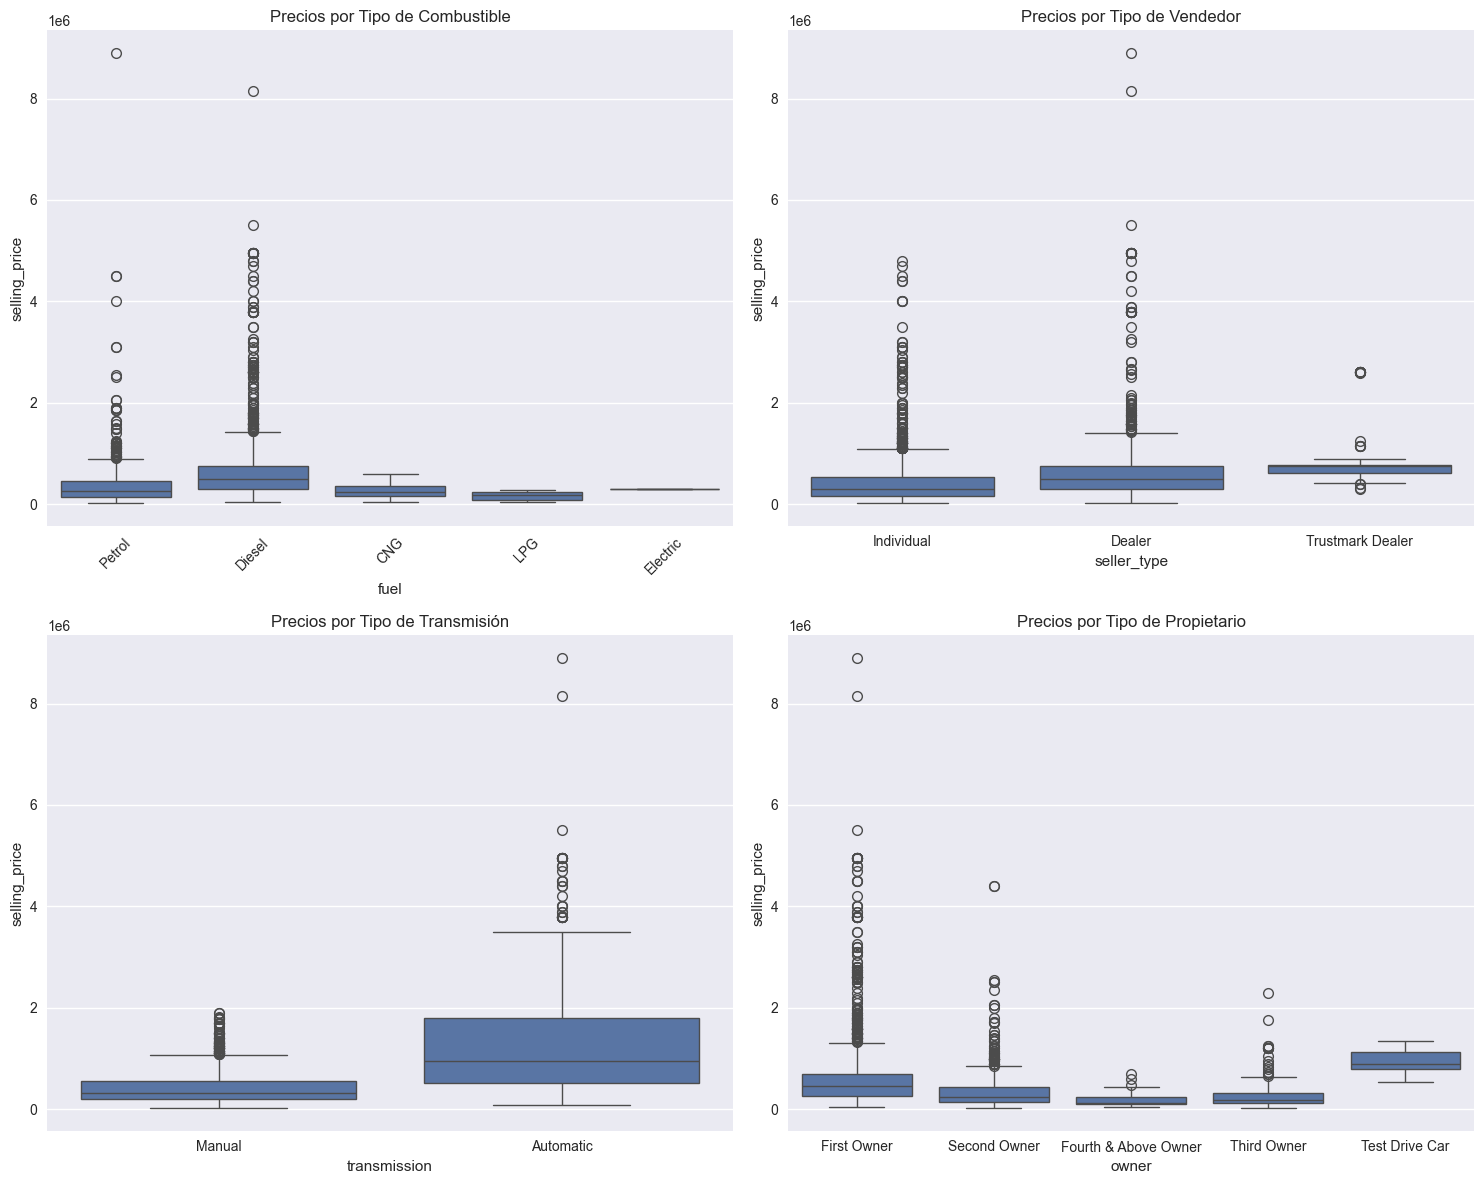

In [14]:
# Análisis por variables categóricas
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.boxplot(data=df, x='fuel', y='selling_price', ax=axes[0,0])
axes[0,0].set_title('Precios por Tipo de Combustible')
axes[0,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='seller_type', y='selling_price', ax=axes[0,1])
axes[0,1].set_title('Precios por Tipo de Vendedor')

sns.boxplot(data=df, x='transmission', y='selling_price', ax=axes[1,0])
axes[1,0].set_title('Precios por Tipo de Transmisión')

sns.boxplot(data=df, x='owner', y='selling_price', ax=axes[1,1])
axes[1,1].set_title('Precios por Tipo de Propietario')

plt.tight_layout()
plt.show()

## 3. Ingeniería de Características

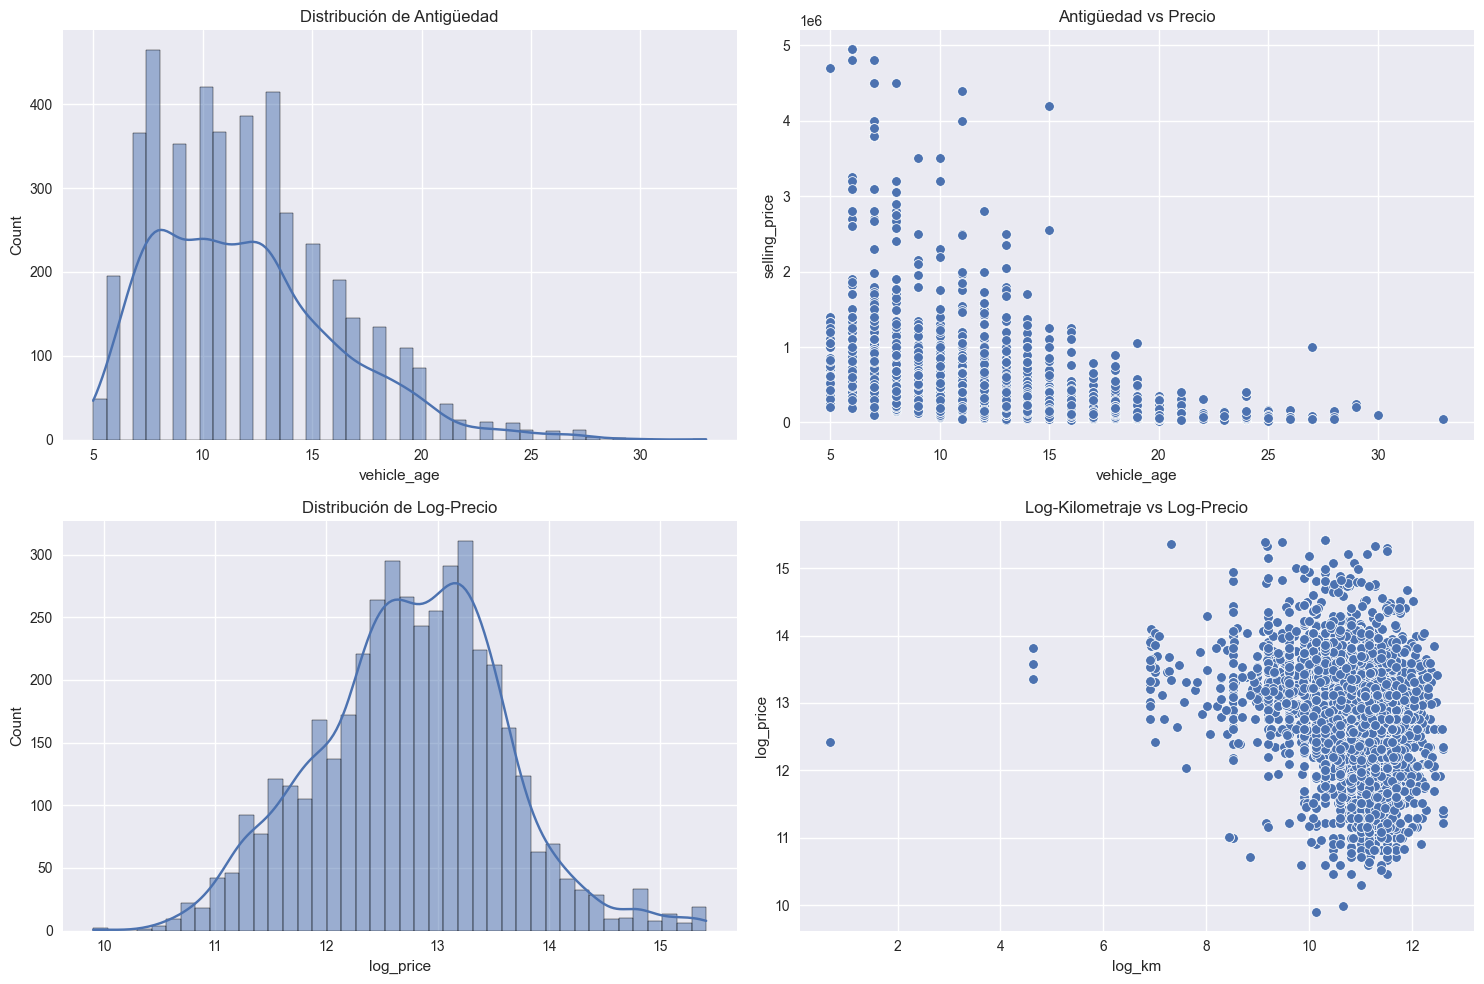

In [15]:
# Crear columna de antigüedad
año_actual = datetime.now().year
df['vehicle_age'] = año_actual - df['year']
df = df.drop('year', axis=1)

# Filtrar outliers
df = df[df['selling_price'] <= 5000000]
df = df[df['km_driven'] <= 300000]

# Transformaciones logarítmicas
df['log_price'] = np.log1p(df['selling_price'])
df['log_km'] = np.log1p(df['km_driven'])

# Visualizar transformaciones
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(df['vehicle_age'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Distribución de Antigüedad')

sns.scatterplot(data=df, x='vehicle_age', y='selling_price', ax=axes[0,1])
axes[0,1].set_title('Antigüedad vs Precio')

sns.histplot(df['log_price'], kde=True, ax=axes[1,0])
axes[1,0].set_title('Distribución de Log-Precio')

sns.scatterplot(data=df, x='log_km', y='log_price', ax=axes[1,1])
axes[1,1].set_title('Log-Kilometraje vs Log-Precio')

plt.tight_layout()
plt.show()

## 4. Preparación para el Modelado

In [16]:
# Codificar variables categóricas
le = LabelEncoder()
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']

for col in categorical_cols:
    df[col + '_encoded'] = le.fit_transform(df[col])

# Preparar features
features = ['vehicle_age', 'log_km'] + [col + '_encoded' for col in categorical_cols]
X = df[features]
y = df['log_price']

# Split de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 5. Entrenamiento del Modelo

In [17]:
# Definir parámetros para GridSearch
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Entrenar modelo con GridSearch
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Mejores parámetros encontrados:")
print(grid_search.best_params_)

Mejores parámetros encontrados:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


## 6. Evaluación del Modelo

Métricas de Evaluación:
MAE: 142,800.91
RMSE: 287,333.96
R² Score: 0.6855


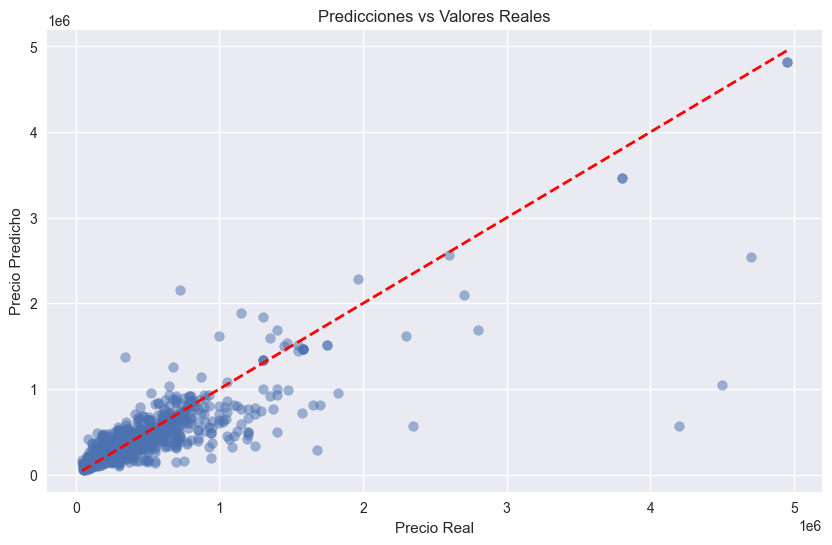

In [18]:
# Hacer predicciones
y_pred_log = grid_search.best_estimator_.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

# Calcular métricas
mae = mean_absolute_error(y_test_original, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))
r2 = r2_score(y_test_original, y_pred)

print("Métricas de Evaluación:")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

# Visualizar predicciones vs valores reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         'r--', lw=2)
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.title('Predicciones vs Valores Reales')
plt.show()

## 7. Guardar el Modelo

In [19]:
# Guardar el mejor modelo
joblib.dump(grid_search.best_estimator_, 'vehicle_model.joblib')
print("Modelo guardado exitosamente!")

Modelo guardado exitosamente!


## 8. Prueba de Predicción

In [20]:
# Crear caso de prueba
caso_prueba = pd.DataFrame([
    {
        'vehicle_age': 3,
        'log_km': np.log1p(50000),
        'fuel_encoded': 0,  # Petrol
        'seller_type_encoded': 1,  # Dealer
        'transmission_encoded': 1,  # Automatic
        'owner_encoded': 0  # First Owner
    }
])

# Realizar predicción
pred_log = grid_search.best_estimator_.predict(caso_prueba)
pred_price = np.expm1(pred_log)

print(f"Precio predicho: ₹{pred_price[0]:,.2f}")

Precio predicho: ₹505,949.96
